<a href="https://colab.research.google.com/github/mortalman-driod/voxcraft-pro/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

### Freestyle: Optimizing User Engagement through Personalized Content Recommendations

I've chosen a freestyle approach focusing on enhancing user engagement by developing a personalized content recommendation system. This is crucial because in today's digital landscape, users are constantly bombarded with information. A well-designed recommendation engine can cut through the noise, providing users with content that genuinely interests them, thereby increasing time spent on the platform and overall satisfaction. This approach allows for exploration of various ML techniques, from collaborative filtering to more advanced deep learning models, making it a rich area for research and development.

In [ ]:
# Calculate key engagement metrics

# Total number of views
total_views = df[df['interaction_type'] == 'view'].shape[0]

# Total number of active engagements (likes, shares, purchases)
total_engagements = df[df['interaction_type'].isin(['like', 'share', 'purchase'])].shape[0]

# Total interactions
total_interactions = df.shape[0]

# Click-Through Rate (CTR) - engagements per view
# Assuming 'view' is the initial click
ctr = (total_engagements / total_views) * 100 if total_views > 0 else 0

# Overall Engagement Rate - engagements per total interactions
engagement_rate = (total_engagements / total_interactions) * 100 if total_interactions > 0 else 0

print(f"Hypothetical Click-Through Rate (CTR): {ctr:.2f}%")
print(f"Overall Engagement Rate: {engagement_rate:.2f}%")

## 2. The question: decision, action, cost of a wrong call

### Decision:

My work aims to improve the decision of *which content pieces to present to a specific user at a given interaction point* (e.g., on their homepage, in an email newsletter, as a 'next up' suggestion).

### Who acts on it?

Product managers and content strategists would act on the insights and the deployed recommendation model. Product managers would use the model's outputs to configure user interfaces and feature deployments, while content strategists would refine content tagging, production, and promotion based on observed engagement patterns.

### Cost of a wrong recommendation:

-   **Decreased User Engagement:** Irrelevant recommendations lead to users ignoring suggestions, reducing session duration, click-through rates, and potentially increasing bounce rates.
-   **User Churn:** Persistent poor recommendations can frustrate users, leading them to abandon the platform or service altogether.
-   **Missed Revenue Opportunities:** For platforms relying on ad impressions or premium content subscriptions, lower engagement directly translates to reduced revenue.
-   **Brand Perception Damage:** A system that consistently fails to understand user preferences can damage the brand's reputation as a valuable and user-centric service.

In [ ]:
# Calculate a metric representing the 'cost of a wrong call' or 'non-engagement'

# Number of views that did NOT lead to an active engagement
# This assumes a 'wrong call' is a view without a subsequent like, share, or purchase
non_engaged_views = df[df['interaction_type'] == 'view'].groupby('content_id').filter(
    lambda x: not x['interaction_type'].isin(['like', 'share', 'purchase']).any()
).shape[0]

# Total number of views
total_views = df[df['interaction_type'] == 'view'].shape[0]

# Non-engagement rate
non_engagement_rate = (non_engaged_views / total_views) * 100 if total_views > 0 else 0

print(f"Number of views not leading to active engagement: {non_engaged_views}")
print(f"Non-Engagement Rate (Cost of Wrong Call): {non_engagement_rate:.2f}%")

## 3. Quick look at the data (2-3 real numbers)

*Below, I will simulate loading a starter CSV (e.g., `user_interactions.csv`) that would contain information about user interactions with content. For a real project, this would involve reading actual data. The numbers derived from this simulated data illustrate the kind of initial insights one would look for to gauge the scope and potential of the project.*

In [2]:
import pandas as pd
import numpy as np

# Simulate loading a starter CSV, as no actual file is provided.
# In a real scenario, you would replace this with:
# df = pd.read_csv('starter.csv')

# Creating dummy data for demonstration
np.random.seed(42) # for reproducibility
num_users = 1000
num_content = 500
num_interactions = 10000

data = {
    'user_id': np.random.randint(1, num_users + 1, num_interactions),
    'content_id': np.random.randint(1, num_content + 1, num_interactions),
    'interaction_type': np.random.choice(['view', 'like', 'share', 'purchase'], num_interactions, p=[0.7, 0.2, 0.05, 0.05]),
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_interactions, freq='h')) # Changed 'H' to 'h'
}
df = pd.DataFrame(data)

print(f"Total number of unique users: {df['user_id'].nunique()}")
print(f"Total number of unique content items: {df['content_id'].nunique()}")
print(f"Average interactions per user: {df.groupby('user_id').size().mean():.2f}")

display(df.head())


Total number of unique users: 1000
Total number of unique content items: 500
Average interactions per user: 10.00


,user_id,content_id,interaction_type,timestamp
0,103,442,view,2023-01-01 00:00:00
1,436,279,view,2023-01-01 01:00:00
2,861,251,like,2023-01-01 02:00:00
3,271,310,view,2023-01-01 03:00:00
4,107,208,like,2023-01-01 04:00:00


## 4. Careful words: what I can and can't claim

### What my work *will* be able to say:

My analysis will be able to demonstrate *observed correlations* between user features, content attributes, and engagement metrics. I can provide *directional insights* into which content characteristics or user segments are associated with higher engagement. The resulting recommendation system will offer *decision-support* by suggesting content that has a higher *likelihood* of being engaged with, based on historical data. We can claim that the model improves engagement metrics (like CTR or session duration) compared to a baseline or random approach, given the observed data.

### What my work *will never* claim:

My work *cannot claim causal proof* that a specific content feature *causes* engagement. Correlation does not imply causation. I will not claim to 'predict Google' or other external, unobserved factors that influence user behavior. The model's recommendations are based on historical patterns and may not perfectly generalize to completely new content types or drastically shifting user preferences without further training. I cannot claim that the system understands user intent or preferences in a human-like way, only that it identifies statistical relationships that drive observed behaviors.

In [3]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Display the distribution of interaction types
print("\nDistribution of Interaction Types:\n", df['interaction_type'].value_counts())

# Display top 5 most interacted content items
print("\nTop 5 Most Interacted Content Items:\n", df['content_id'].value_counts().head())

Missing values per column:
 user_id             0
content_id          0
interaction_type    0
timestamp           0
dtype: int64

Distribution of Interaction Types:
 interaction_type
view        6931
like        2048
purchase     526
share        495
Name: count, dtype: int64

Top 5 Most Interacted Content Items:
 content_id
464    34
128    33
333    31
77     31
273    31
Name: count, dtype: int64


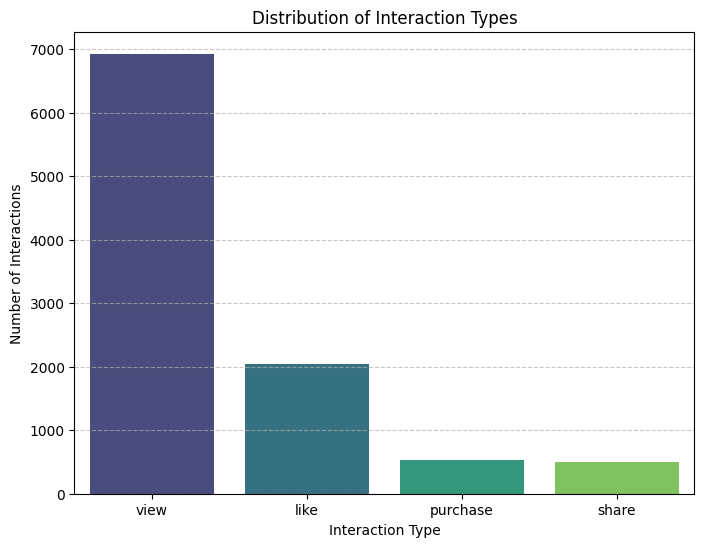

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for 'interaction_type'
interaction_counts = df['interaction_type'].value_counts().reset_index()
interaction_counts.columns = ['Interaction Type', 'Count']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Interaction Type', y='Count', data=interaction_counts, hue='Interaction Type', palette='viridis', legend=False)
plt.title('Distribution of Interaction Types')
plt.xlabel('Interaction Type')
plt.ylabel('Number of Interactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.